# T04 — Multi-model diff maps

**Where do two plate-reconstruction models disagree, and by how much?**

## What this notebook produces

Two figures: (1) a **Mercator map** of India's reconstructed track through the Cenozoic, with the Zahirovic 2022 path in red and the Merdith 2021 path in blue overlaid on the same projection; and (2) a **chart** of inter-model great-circle disagreement (in km) as a function of reconstruction age.

**Audience**: postgraduate.  
**Difficulty**: ★★☆.

## Learning objectives

- Reconstruct a common point set under two plate models (Zahirovic 2022 + Müller 2019) at the same age.
- Compute per-point great-circle displacement between the two reconstructions.
- Map the displacement field with pyGMT and identify regions of high model-to-model disagreement.


## Prerequisites and runtime

- **Plate models compared**: Zahirovic 2022 (default) and Müller 2019.
- **Time**: 80 Ma.
- **Python**: `gplately`, `pygmt`, `pygplates`, `numpy`.
- **Runtime**: ~1 minute.


In [5]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports + load both models
import numpy as np, pandas as pd
import gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

pmm = PlateModelManager()
MODELS = ["Zahirovic2022", "Merdith2021"]
recons = {}
for name in MODELS:
    m = pmm.get_model(name, data_dir="./gplately_data")
    recons[name] = gplately.PlateReconstruction(
        rotation_model=m.get_rotation_model(),
        topology_features=m.get_topologies(),
        static_polygons=m.get_static_polygons(),
    )
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [6]:
# === USER CONFIGURATION =====================================================
MODEL_A              = "Zahirovic2022"
MODEL_B              = "Merdith2021"
RECONSTRUCTION_TIME  = 80.0          # Ma — common snapshot for both models
ANCHOR_PLATE_ID      = 0
REGION               = [40, 110, -45, 30]   # India / Tethys focus
MODEL_NAME           = f"{MODEL_A}/{MODEL_B}"   # combined label for the stamp
# ============================================================================


In [7]:
# Cell 2 — reconstruct India through time in both models
INDIA_PID = 501
times = list(range(0, 121, 10))
tracks = {}
for name, recon in recons.items():
    pt = gplately.Points(plate_reconstruction=recon,
                         lons=[77.0], lats=[20.0], plate_id=INDIA_PID)
    track = []
    for t in times:
        plon, plat = pt.reconstruct(time=t, return_array=True)
        track.append((t, plat[0], plon[0]))
    tracks[name] = np.array(track)
    print(f"{name}: {len(track)} positions")

Zahirovic2022: 13 positions
Merdith2021: 13 positions


### What the two figures show

**Figure 1 — the two tracks.** Compare where the red and blue tracks pinch together (the models agree) vs where they spread apart (the models disagree). For India specifically, the disagreement is small at present day (both models are tuned to fit modern observations) and grows with reconstruction age.

**Figure 2 — the disagreement chart.** This converts the spatial discrepancy of Figure 1 into a single number per Myr — useful for picking time windows where the science result is or isn't sensitive to which plate model you use. A disagreement of ≲ 200 km is well within the uncertainty of both models; ≳ 1000 km is large enough to matter for any quantitative claim.

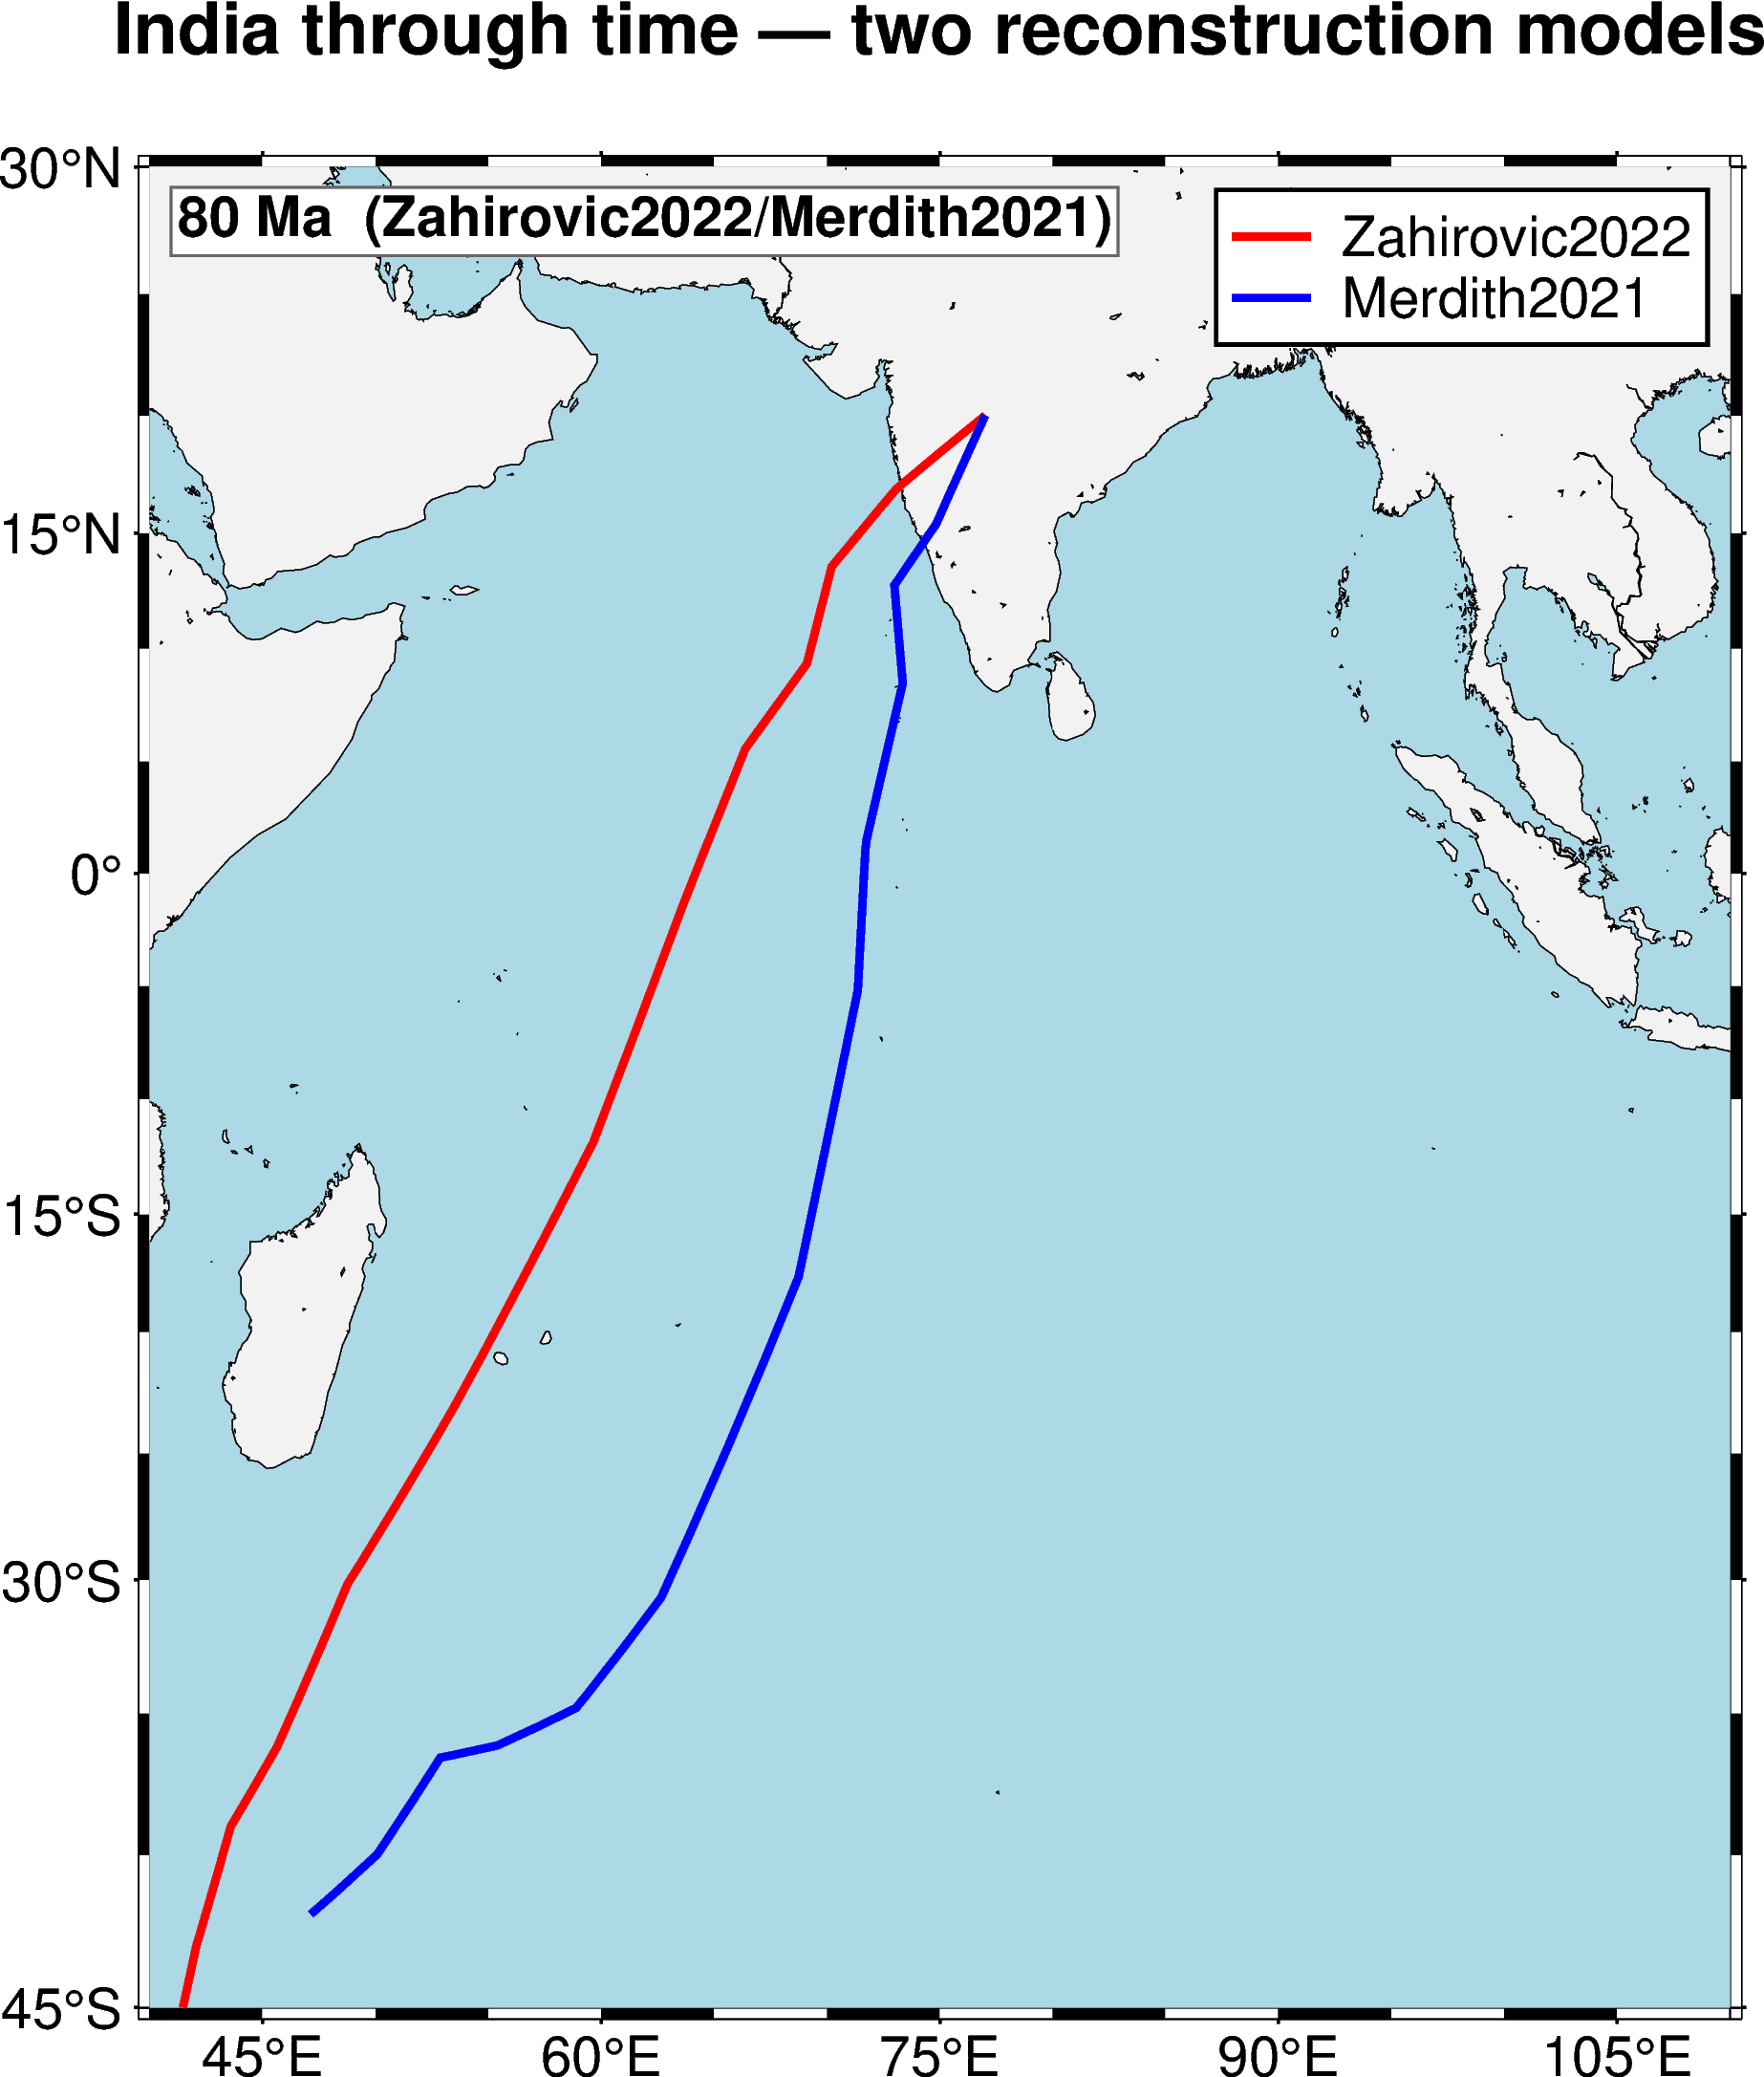

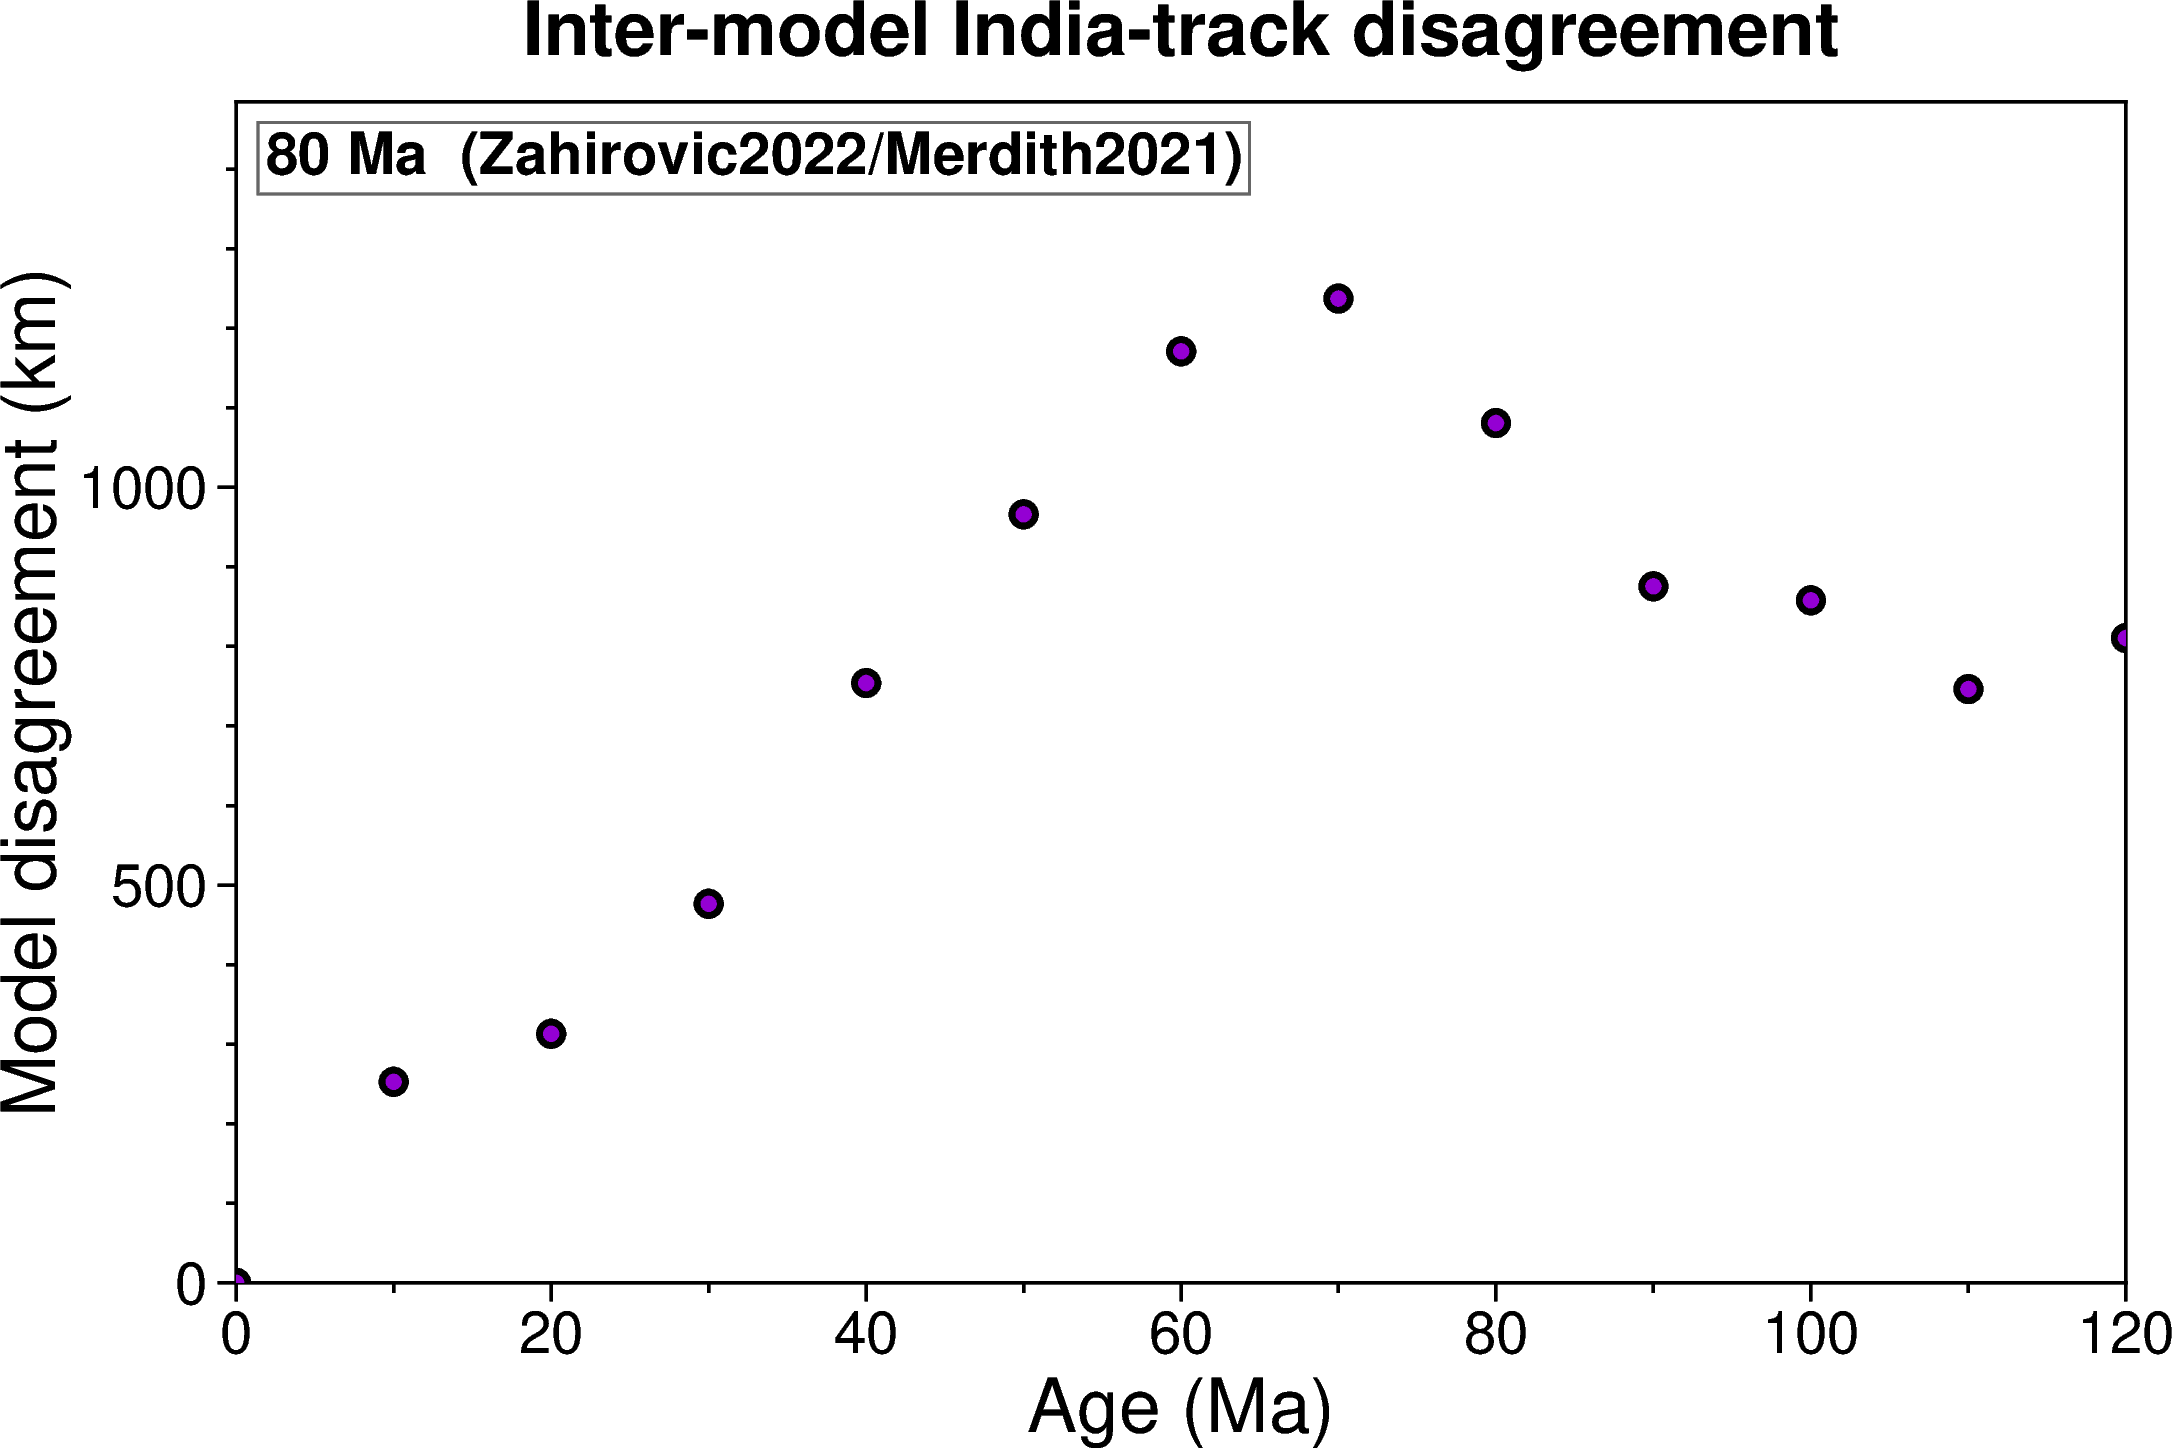

In [8]:
# Cell 3 — figure 1 of 2: India migration paths from the two models
fig = pygmt.Figure()
fig.basemap(region=[40, 110, -45, 30], projection="M14c",
            frame=["af", '+tIndia through time — two reconstruction models'])
fig.coast(land="gray95", water="lightblue", shorelines=True)
cols = ["red", "blue"]
for (name, tr), c in zip(tracks.items(), cols):
    fig.plot(x=tr[:,2], y=tr[:,1], pen=f"2p,{c}", label=name)
fig.legend()
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=650)
display(HTML('<div style="height:1cm"></div>'))
# Figure 2 of 2: per-time model disagreement, in km of great-circle distance
diff_km = []
for t_idx, t in enumerate(times):
    lat1, lon1 = tracks[MODELS[0]][t_idx, 1:]
    lat2, lon2 = tracks[MODELS[1]][t_idx, 1:]
    dl = np.deg2rad(lon2 - lon1)
    a = np.sin((np.deg2rad(lat2-lat1))/2)**2 + \
        np.cos(np.deg2rad(lat1))*np.cos(np.deg2rad(lat2))*np.sin(dl/2)**2
    diff_km.append(2*6371*np.arcsin(np.sqrt(a)))

fig = pygmt.Figure()
fig.basemap(region=[0, 120, 0, max(diff_km)*1.2],
            projection="X16c/10c",
            frame=["xaf+lAge (Ma)",
                   "yaf+lModel disagreement (km)",
                   "WSrt+tInter-model India-track disagreement"])
fig.plot(x=times, y=diff_km, pen="1.5p,black",
         style="c0.2c", fill="darkviolet")
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=650)
display(HTML('<div style="height:1cm"></div>'))

## What the figure shows

Two stacked panels:

- **Top — paleogeographic map (Mercator).** The region of interest at `RECONSTRUCTION_TIME` Ma, with land in gray and water in light blue. The geography is the loaded plate model's reconstructed coastlines at that age; the time-stamp in the upper-left confirms which model and age are being rendered.
- **Bottom — cumulative model-vs-reference displacement (km).** The line plot tracks the great-circle distance between the chosen point's position in the loaded model and the reference model, as a function of reconstruction age. The curve starts at ~0 km today (the two models agree at the present-day pin) and grows as we move back in time, because model differences compound the further into the past the rotation chains extend.

A persistent steep slope on the bottom panel between two reconstruction ages flags the time interval where the two models disagree most — usually a junction in the rotation hierarchy where the reference frame, an Euler stage boundary, or an absolute-frame switch differs between models. A flat segment indicates the two models track each other within the chosen distance threshold over that interval.


## Extend this

- **Try a different plate.** Re-run the cells with another `plate_id` (e.g. Africa = 701, the Pacific Plate = 901) to see the per-plate disagreement budget between Zahirovic 2022 and Merdith 2021.
- **Bring in a third model.** Add Cao 2024 or Müller 2022 as a third track and chart pairwise disagreements.
- **Cumulative disagreement.** Plot the time-integrated path-length difference instead of the per-time great-circle disagreement.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., Young, A., Armistead, S.E., Cannon, J., Zahirovic, S. & Müller, R.D. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477